In [2]:
from utils.binaries import *
from utils.plotting import *

03:10:10 (  +31.0s) [INFO   ] -- import logging


03:10:10 (  +181ms) [INFO   ] -- import numpy as np
03:10:10 (    +5ms) [INFO   ] -- import uncertainties
03:10:10 (    +5ms) [INFO   ] -- import uncertainties
03:10:11 (  +756ms) [INFO   ] -- import pandas as pd
03:10:11 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
03:10:11 (    +1ms) [INFO   ] -- import binaries.tools as tools
03:10:11 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
03:10:11 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
03:10:11 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
03:10:11 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
03:10:11 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
03:10:11 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
03:10:11 (  +481ms) [INFO   ] -- import matplotlib.pyplot as plt
03:10:12 (  +714ms) [INFO   ] -- import 

In [4]:
olo_x, olo_y = np.loadtxt("olomouc.csv", delimiter=',', unpack=True)
kit_x, kit_y = np.loadtxt("kit_results.txt", unpack=True)

In [16]:
from scipy.optimize import curve_fit

def inverse_view_factor(z, offset, r=0, R=0):

    z = z - offset
    a, b = R/z, r/z
    x = 1 + np.pow(a, -2) + np.pow(b/a, 2)
    y = np.sqrt(np.pow(x, 2) - 4 * np.pow(b/a, 2))

    return 0.5 * (x - y)

popt_olo, pcov_olo = curve_fit(inverse_view_factor, olo_x, olo_y * 1e9)
popt_kit, pcov_kit = curve_fit(inverse_view_factor, kit_x * 1000, kit_y)

03:17:03 (   +7.0s) [DEBUG  ] -- font size set to 9.5
03:17:03 (    +2ms) [DEBUG  ] -- label size set to 13.0
03:17:03 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
03:17:03 (    +1ms) [DEBUG  ] -- markersize set to 2.0
03:17:03 (    +1ms) [DEBUG  ] -- usetex set to False


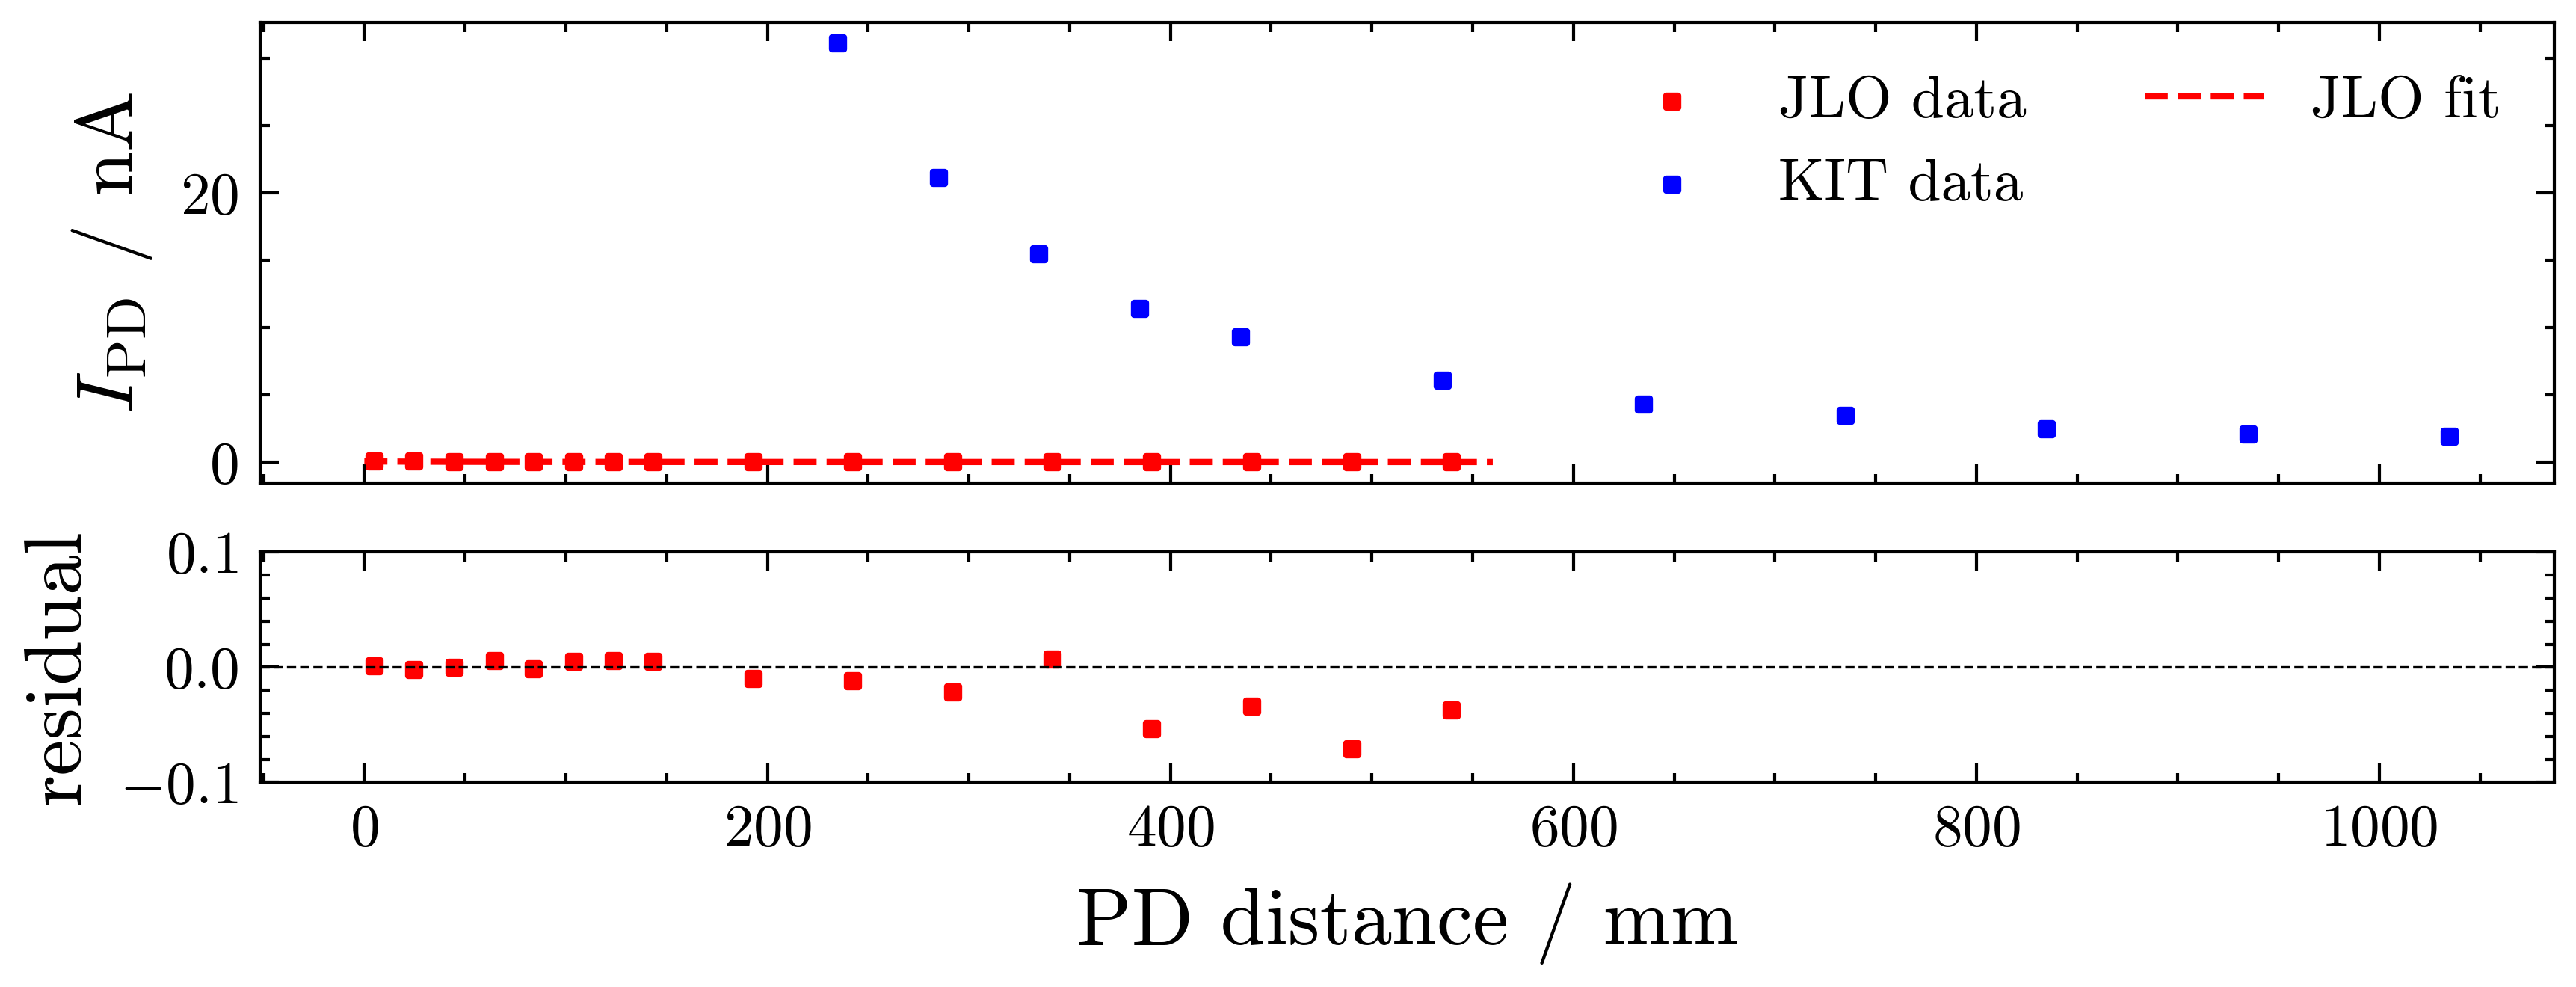

In [22]:
set_plt_style("slim")

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.5], sharex=True)

X = np.linspace(0, 560, 500)

ax1.scatter(olo_x, olo_y * 1e9, label="JLO data", marker='s', c='r')
ax1.scatter(kit_x * 1000, kit_y, label="KIT data", marker='s', c='b')


ax1.plot(X, inverse_view_factor(X, *popt_olo), marker='none', label="JLO fit", c='r', ls='--')
ax1.set_ylabel(r"$I_\mathrm{PD}$ / nA")
ax2.set_ylabel(r"residual")
ax2.set_xlabel(r"PD distance / mm")
ax1.legend(ncol=2)

ax2.scatter(olo_x, (olo_y * 1e9 - inverse_view_factor(olo_x, *popt_olo))/inverse_view_factor(olo_x, *popt_olo), marker='s', c='r')

ax2.set_ylim(-0.1, 0.1)
ax2.axhline(0, c='k', ls='--', lw=0.4)
# plt.yscale("log")

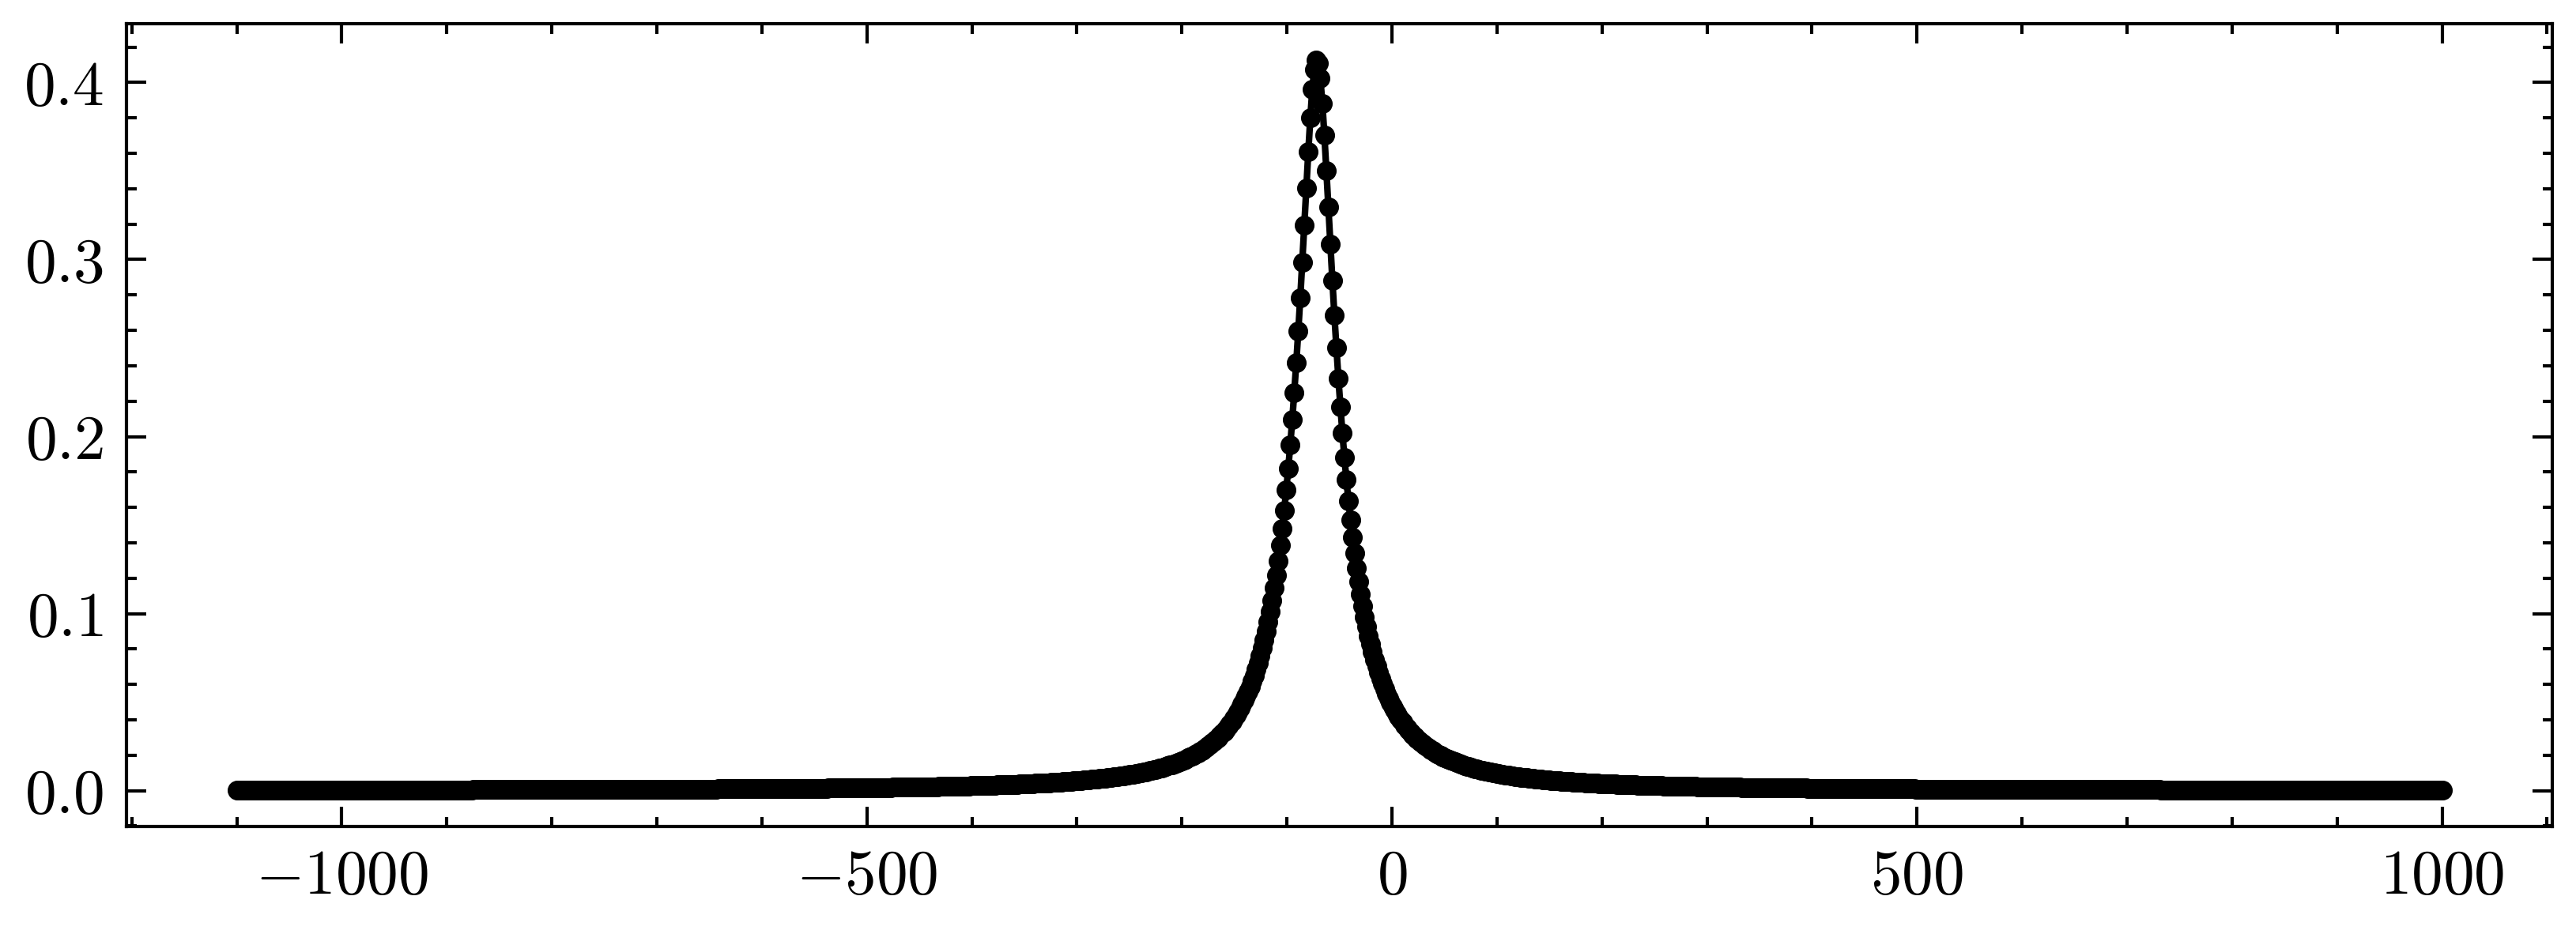

In [6]:
R = np.linspace(-1100, 1000, 1100)

plt.plot(R, inverse_view_factor(R, *popt_olo))